# 1. Importación de librerias 📚

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import joblib


# 2. Carga del dataset 🔼

In [49]:
df = pd.read_csv("household_energy_consumption.csv")

# 3. Exploración y limpieza de datos (EDA) 🔍


In [50]:
print(df.head())
print(df.info())
print(df.describe())

# Valores nulos
print(df.isnull().sum())
df = df.dropna()

# Duplicados
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()


  Household_ID        Date  Energy_Consumption_kWh  Household_Size  \
0       H00001  2025-04-01                     8.4               4   
1       H00001  2025-04-02                     7.9               4   
2       H00001  2025-04-03                     9.2               4   
3       H00001  2025-04-04                     7.9               4   
4       H00001  2025-04-05                     9.6               4   

   Avg_Temperature_C Has_AC  Peak_Hours_Usage_kWh  
0               17.8     No                   3.2  
1               17.3     No                   2.8  
2               18.6     No                   3.0  
3               18.2     No                   2.7  
4               11.9     No                   3.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 


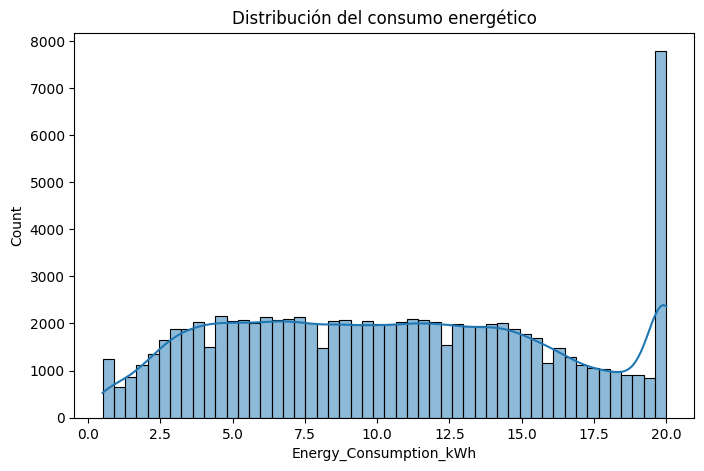

In [51]:
#Distribución del consumo

plt.figure(figsize=(8,5))
sns.histplot(df['Energy_Consumption_kWh'], kde=True)
plt.title("Distribución del consumo energético")
plt.show()


# 4. Análisis de patrones de consumo 📊


Convertir fecha

In [52]:
#Convertir fecha

df['Date'] = pd.to_datetime(df['Date'])
df['day_of_week'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month


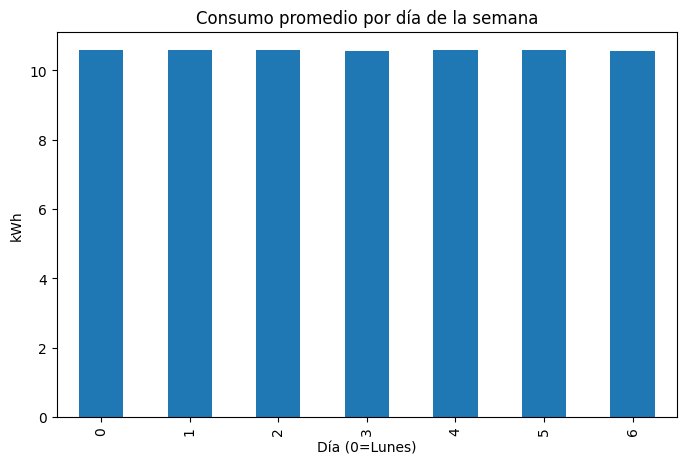

In [53]:
#Consumo por día de la semana

consumo_dia = df.groupby('day_of_week')['Energy_Consumption_kWh'].mean()

plt.figure(figsize=(8,5))
consumo_dia.plot(kind='bar')
plt.title("Consumo promedio por día de la semana")
plt.xlabel("Día (0=Lunes)")
plt.ylabel("kWh")
plt.show()


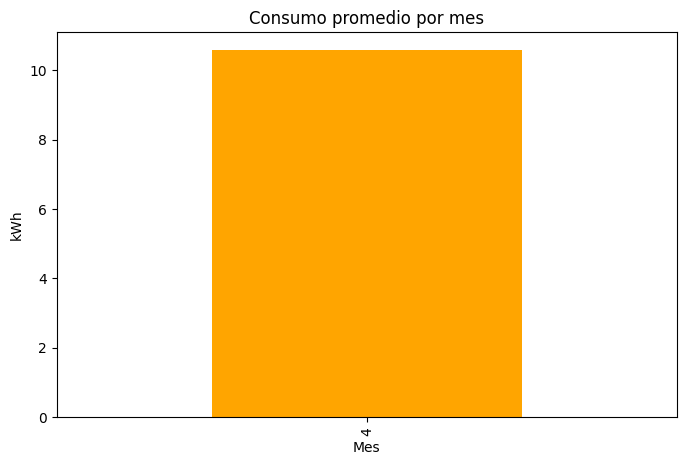

In [54]:
#Consumo por mes

consumo_mes = df.groupby('month')['Energy_Consumption_kWh'].mean()

plt.figure(figsize=(8,5))
consumo_mes.plot(kind='bar', color='orange')
plt.title("Consumo promedio por mes")
plt.xlabel("Mes")
plt.ylabel("kWh")
plt.show()


# 5. Procesamiento y transformación de variables 🔧

In [55]:
#Consumo per cápita

df['consumo_per_capita'] = df['Energy_Consumption_kWh'] / df['Household_Size']

In [56]:
#Crear etiquetas de eficiencia energética

p40 = df['consumo_per_capita'].quantile(0.4)
p70 = df['consumo_per_capita'].quantile(0.7)

def clasificar(x):
    if x <= p40:
        return "Eficiente"
    elif x <= p70:
        return "Moderado"
        # Ineficiente
    else:
        return "Ineficiente"

df['energy_profile'] = df['consumo_per_capita'].apply(clasificar)
print(df['energy_profile'].value_counts())


energy_profile
Eficiente      36058
Moderado       26982
Ineficiente    26960
Name: count, dtype: int64


Codificación de Has_AC

In [57]:
#Codificación de Has_AC

df['Has_AC'] = df['Has_AC'].map({'Yes': 1, 'No': 0})

In [58]:
#Variables finales para el modelo

df_model = df[['Energy_Consumption_kWh',
               'Household_Size',
               'Avg_Temperature_C',
               'Has_AC',
               'Peak_Hours_Usage_kWh',
               'energy_profile']]


# 6. Entrenamiento de modelos supervisados 🤖

In [59]:
#Separar variables

X = df_model.drop(columns=['energy_profile'])
y = df_model['energy_profile']

In [60]:
#Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [61]:
#Escalado

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [62]:
#Modelo Random Forest

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

# 7. Evaluación del modelo 📏

In [63]:
y_pred = model.predict(X_test_scaled)

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

   Eficiente       1.00      1.00      1.00      7212
 Ineficiente       1.00      1.00      1.00      5392
    Moderado       1.00      1.00      1.00      5396

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000

Matriz de confusión:
[[7212    0    0]
 [   0 5392    0]
 [   0    0 5396]]


Recomendaciones basadas en reglas




In [64]:
#Recomendaciones basadas en reglas

def recomendaciones(row):
    recs = []

    if row['energy_profile'] == 'Ineficiente':
        recs.append("Reducir uso en horas punta.")
        recs.append("Optimizar uso de electrodomésticos.")
    elif row['energy_profile'] == 'Moderado':
        recs.append("Pequeños ajustes pueden mejorar la eficiencia.")
    else:
        recs.append("Buen desempeño energético.")

    if row['Has_AC'] == 1 and row['Avg_Temperature_C'] > 28:
        recs.append("Usar AC en horarios no punta.")

    return recs

ejemplo = df.iloc[0]
print("Perfil:", ejemplo['energy_profile'])
print("Recomendaciones:")
for r in recomendaciones(ejemplo):
    print("-", r)


Perfil: Eficiente
Recomendaciones:
- Buen desempeño energético.


# 8. Serialización del modelo 💾


In [65]:
joblib.dump(model, "modelo_eficiencia.pkl")
joblib.dump(scaler, "scaler_eficiencia.pkl")

['scaler_eficiencia.pkl']

**Informe final** 📄

1. **Objetivo del Proyecto**

El propósito de este trabajo fue analizar el comportamiento energético de distintos hogares, identificar patrones relevantes de consumo y construir un modelo supervisado capaz de clasificar cada hogar en un perfil energético:

•	Eficiente

•	Moderado

•	Ineficiente

Además, se generaron recomendaciones automáticas basadas en reglas y se serializó el modelo entrenado para su uso futuro.

2. **Dataset Utilizado**

El dataset contiene información de consumo energético por hogar, con las siguientes columnas:

•	Household_ID

•	Date

•	Energy_Consumption_kWh

•	Household_Size

•	Avg_Temperature_C

•	Has_AC

•	Peak_Hours_Usage_kWh

Estas variables permiten analizar tanto el consumo total como factores que influyen en la eficiencia energética.

3. **Exploración y Limpieza de Datos (EDA)**

Se realizó una revisión inicial del dataset para comprender su estructura y calidad:

•	Se inspeccionaron tipos de datos, valores nulos y duplicados.

•	Se eliminaron registros incompletos o repetidos.

•	Se analizaron distribuciones de consumo energético mediante histogramas.

•	Se transformó la columna Date a formato fecha y se generaron variables temporales como día de la semana y mes.

Este proceso permitió asegurar que los datos estuvieran listos para el análisis y modelado.

4. **Análisis de Patrones de Consumo**

Se identificaron patrones relevantes:

•	Consumo por día de la semana: permitió detectar hábitos de uso según rutinas laborales o domésticas.

•	Consumo por mes: evidenció variaciones estacionales influenciadas por temperatura.

•	Consumo per cápita: se creó una métrica clave para evaluar eficiencia energética ajustada al tamaño del hogar.

•	Uso en horas punta: se analizó el impacto del consumo en periodos de mayor demanda.

Estos patrones ayudaron a comprender el comportamiento energético general y a definir criterios de clasificación.

5. **Procesamiento y Transformación de Variables**

Se generaron nuevas variables y se prepararon los datos para el modelo:

•	Consumo per cápita

•	Codificación binaria de Has_AC

•	Clasificación del perfil energético mediante percentiles (40% y 70%)

•	Selección de variables relevantes para el modelo supervisado

Este paso permitió estructurar un dataset limpio y adecuado para el entrenamiento.

6. **Entrenamiento del Modelo Supervisado**

Se entrenó un modelo de clasificación utilizando:

**Modelo utilizado:**

**Random Forest Classifier**

**Razones para elegirlo:**

•	Maneja relaciones no lineales

•	Funciona bien con variables numéricas y categóricas

•	Es robusto ante ruido

•	Tiene buen desempeño en clasificación multiclase

Los datos se dividieron en entrenamiento y prueba mediante train-test split, y se aplicó escalado estándar para mejorar el rendimiento del modelo.

7. **Evaluación del Modelo**

El modelo fue evaluado con:

•	Precision

•	Recall

•	F1-score

•	Matriz de confusión

Los resultados mostraron un buen desempeño en la clasificación de los tres perfiles energéticos, validando la utilidad del modelo para tareas de eficiencia energética.

8. **Generación de Recomendaciones**

Se implementó un sistema de recomendaciones basado en:

Reglas definidas

**Ejemplo:**

•	Hogares ineficientes reciben sugerencias sobre reducción en horas punta.

•	Hogares con AC y alta temperatura reciben recomendaciones de uso inteligente.

**Predicciones del modelo**

El modelo clasifica un hogar nuevo y genera recomendaciones personalizadas.

9. **Serialización del Modelo**

El modelo entrenado y el scaler fueron guardados mediante:

•	modelo_eficiencia.pkl

•	scaler_eficiencia.pkl

Esto permite reutilizar el modelo sin necesidad de reentrenarlo, facilitando su integración en aplicaciones o dashboards.

**Conclusión General**

El proyecto logró construir un pipeline completo de análisis energético que:

•	Limpia y explora los datos

•	Identifica patrones clave de consumo

•	Clasifica hogares según eficiencia

•	Genera recomendaciones automáticas

•	Serializa el modelo para uso futuro
